# 🛡️ Fraud Detection: Visual Exploratory Data Analysis (EDA)
**Project:** Real-time Fraud Detection  
**Goal:** Identify patterns in transaction data that distinguish legitimate purchases from fraudulent ones.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Settings for beauty
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data - Note the '../' because we are inside the notebooks folder
df = pd.read_csv('../data/creditcard.csv')
print(f"Dataset loaded: {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset loaded: 284807 rows and 31 columns.


## 1. The Class Imbalance Problem
Fraudulent transactions are extremely rare. Let's visualize the gap between 'Normal' (0) and 'Fraud' (1).

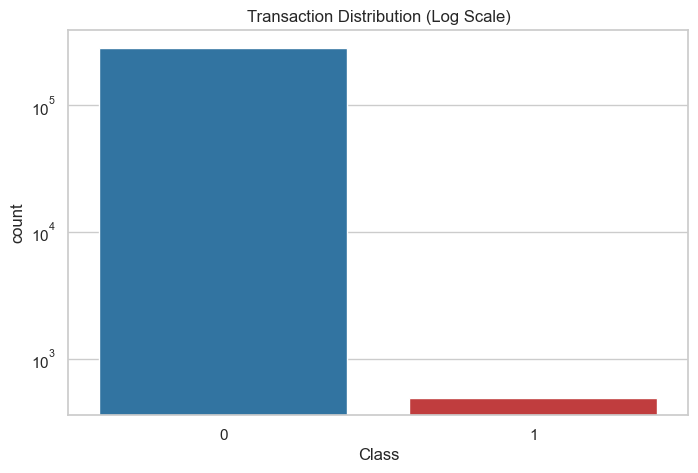

In [4]:
# Using a Log scale to make the tiny fraud bar visible
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Class', data=df, palette=['#1f77b4', '#d62728'])
ax.set_yscale('log')
plt.title('Transaction Distribution (Log Scale)')
plt.show()

## Correlation Heatmap
We want to see which features have the strongest relationship with Fraud (Class).


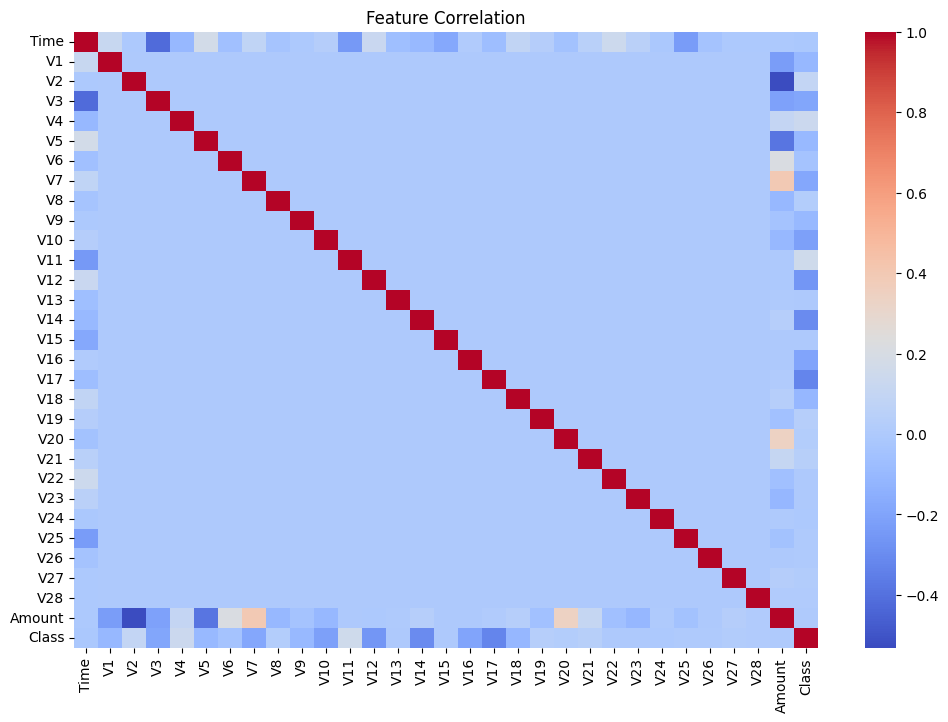

In [2]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation")
plt.show()

## 3. Does Amount Matter?
Let's see if fraud happens mostly on large purchases or small "test" charges.

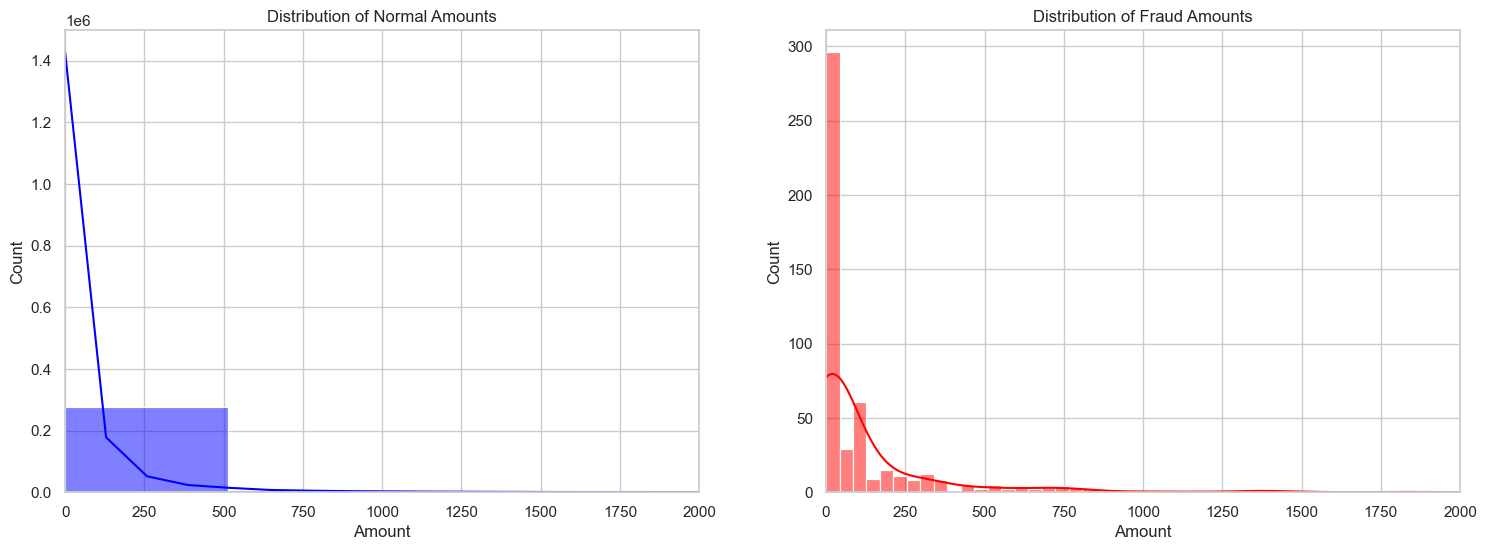

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Normal
sns.histplot(df[df['Class'] == 0]['Amount'], bins=50, ax=ax1, color='blue', kde=True)
ax1.set_title('Distribution of Normal Amounts')
ax1.set_xlim(0, 2000)

# Fraud
sns.histplot(df[df['Class'] == 1]['Amount'], bins=50, ax=ax2, color='red', kde=True)
ax2.set_title('Distribution of Fraud Amounts')
ax2.set_xlim(0, 2000)

plt.show()

## 4. Deep Dive: Outlier Detection
Certain features like `V14` and `V17` often show huge differences between normal and fraud cases.

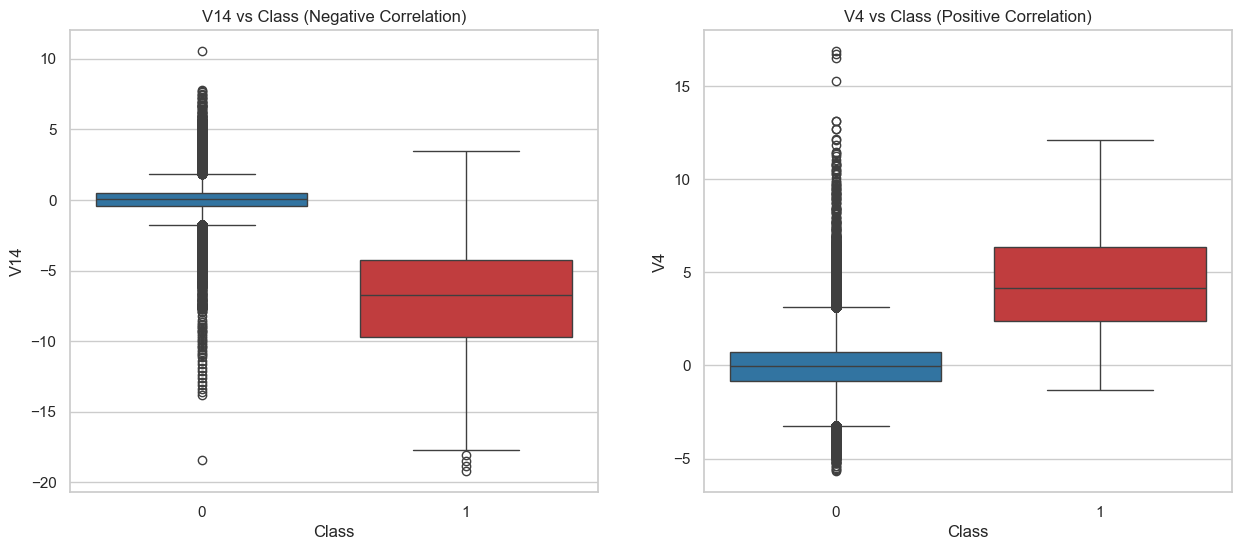

In [6]:
f, axes = plt.subplots(ncols=2, figsize=(15, 6))

# Negative Correlation
sns.boxplot(x="Class", y="V14", data=df, palette=['#1f77b4', '#d62728'], ax=axes[0])
axes[0].set_title('V14 vs Class (Negative Correlation)')

# Positive Correlation
sns.boxplot(x="Class", y="V4", data=df, palette=['#1f77b4', '#d62728'], ax=axes[1])
axes[1].set_title('V4 vs Class (Positive Correlation)')

plt.show()